In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import pairwise_distances
from matplotlib.patches import Patch
import matplotlib as mpl
mpl.rcParams["mathtext.fontset"] = 'cm'
mpl.rcParams["font.size"] = 15
mpl.rcParams["figure.autolayout"] = True

In [3]:
interaction_data = pd.read_csv('data/training_data.tsv', delimiter='\t')

In [4]:
rows = interaction_data.index.str.startswith('CAN01_')
cols = interaction_data.columns.str.endswith('_phage')
phage_pangenome = interaction_data.iloc[rows, cols]

In [5]:
# Calcular matriz de distancias usando Jaccard distance
# Jaccard similarity = |A ∩ B|/|A ∪ B|
# ¿ Jaccard distance = 1 - Jaccard similarity ?

N = sum(rows)
jaccard_distance_matrix = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        intersection = sum(phage_pangenome.iloc[i].values * phage_pangenome.iloc[j].values)
        union = sum((phage_pangenome.iloc[i].values + phage_pangenome.iloc[j].values) > 0)
        jaccard_distance_matrix[i, j] = 1 - intersection/union

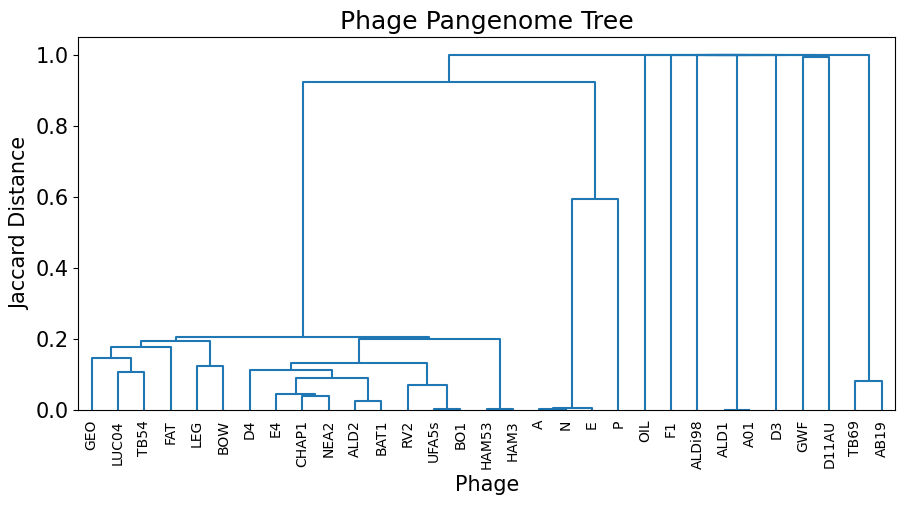

In [6]:
# Dendogram

metric = 'jaccard'

px = 1/plt.rcParams['figure.dpi']

# Compute Jaccard distance
# distance_matrix = pairwise_distances(phage_pangenome, metric="jaccard") # jaccard or hamming?

# Hierarchical clustering (average linkage = good default)
Z = linkage(phage_pangenome, method='average', metric=metric, optimal_ordering=True)

# Plot dendrogram
plt.figure(0, figsize=(930*px, 530*px))
fig, ax = plt.subplots(num=0)

dendrogram(Z, labels=[l[6:] for l in phage_pangenome.index], leaf_rotation=90, color_threshold=0, leaf_font_size=10)
plt.title(f"Phage Pangenome Tree")# ({metric})")
plt.ylabel("Jaccard Distance")
plt.xlabel('Phage')
plt.tight_layout()

# from matplotlib.lines import Line2D

# cluster1 = ['A01']
# cluster2 = ['ALD1']

# y = average_distance(cluster1, cluster2)
# line = Line2D([0, 300], [y, y], color='C1', linestyle='--')
# ax.add_line(line)

plt.show()

In [7]:
# Distancia a primer vecino:

S_1n = np.zeros(N)

for i in range(N):
    aux = np.delete(jaccard_distance_matrix[i], i)
    S_1n[i] = min(aux)

In [8]:
# Distancia promedio

S_avg = np.zeros(N)

for i in range(N):
    aux = np.delete(jaccard_distance_matrix[i], i)
    S_avg[i] = np.mean(aux)


In [9]:
# Harmonic mean

S_inv_avg = np.zeros(N)

for i in range(N):
    aux = np.delete(jaccard_distance_matrix[i]*1., i)
    S_inv_avg[i] = np.mean(aux**-1)**-1

/var/folders/3m/7byy2w5d36l3dg7vvm8qwksm0000gp/T/ipykernel_14461/3995085199.py:7: RuntimeWarning: divide by zero encountered in reciprocal
  S_inv_avg[i] = np.mean(aux**-1)**-1


In [10]:
# Export data

phage_names = [l[6:] for l in phage_pangenome.index]
data = np.array([phage_names, S_1n, S_avg, S_inv_avg]).T

data = pd.DataFrame(data, columns=['phage', '1st neighbour distance', 'mean distance', 'IMID'])
data.to_csv('data/feature_distances.csv', index=False)